##   1 — Install & Import Libraries

In [1]:
# Install required libraries (run once in Colab)
!pip install lightgbm imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


##   2 — Load Dataset

In [2]:
# ─── If running on Colab, upload the file first ───
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('gold.patient_flat-DiseaseFlag.csv')

print(f'Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {df.columns.tolist()}')
df.head()

Saving gold.patient_flat-DiseaseFlag.csv to gold.patient_flat-DiseaseFlag.csv
Shape: (280985, 39)
Columns (39): ['composite_key', 'age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'age', 'age_normalized', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status', 'source_dataset', 'disease_flags', 'sublabel', 'label']


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal


##   3 — EDA: Basic Info & Missing Values

In [3]:
print('=== Data Types & Non-Null Counts ===')
df.info()

print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print('✅ No missing values found!')
else:
    print(missing)

print('\n=== Duplicate Rows ===')
duplicates_count = df.duplicated().sum()
print(f'Duplicates found: {duplicates_count}')
if duplicates_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'✅ Duplicates removed. New shape: {df.shape}')
else:
    print('✅ No duplicates found.')

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280985 entries, 0 to 280984
Data columns (total 39 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   composite_key         280985 non-null  object 
 1   age_level             280985 non-null  object 
 2   gender                280985 non-null  object 
 3   bmi_level             280985 non-null  object 
 4   smoking               280985 non-null  object 
 5   diabetes              280985 non-null  object 
 6   age                   280985 non-null  int64  
 7   age_normalized        280985 non-null  float64
 8   bmi                   280985 non-null  float64
 9   hypertension          280985 non-null  float64
 10  heart_disease         280985 non-null  float64
 11  HbA1c_level           280985 non-null  float64
 12  glucose               280985 non-null  float64
 13  cholesterol           280985 non-null  float64
 14  sleep_hours    

##   4 — EDA: Target Distribution

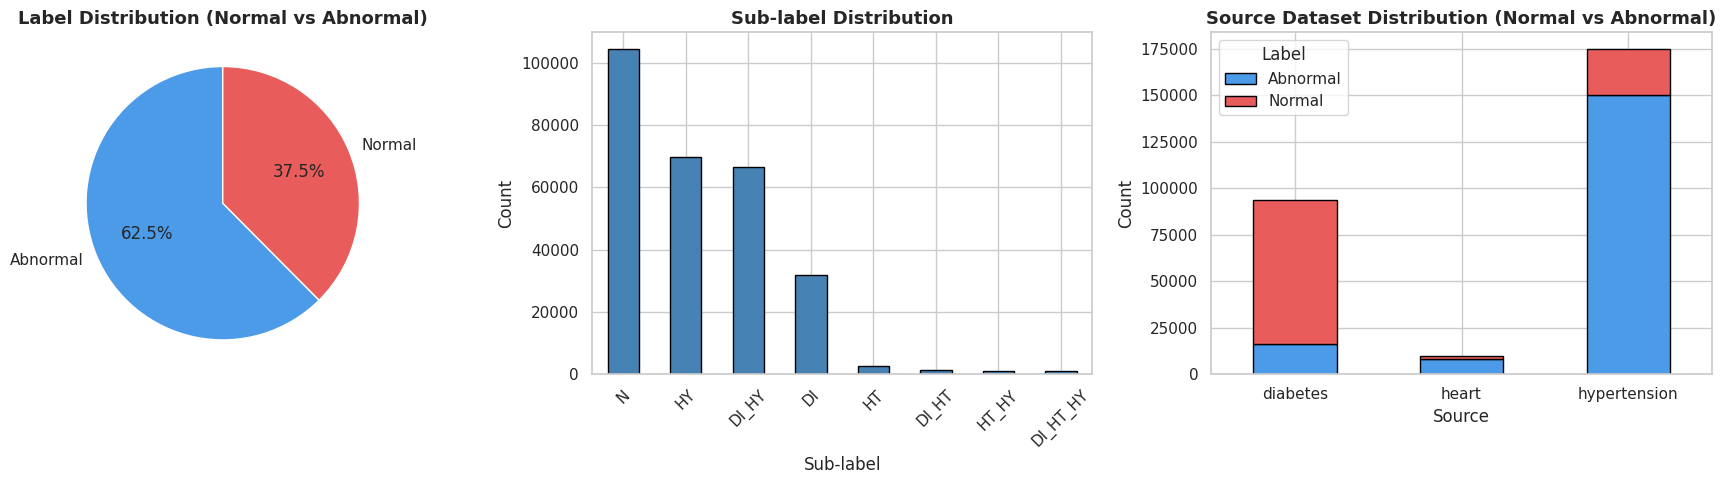

Label counts:
label
Abnormal    174053
Normal      104648
Name: count, dtype: int64

Sublabel counts:
sublabel
N           104648
HY           69787
DI_HY        66472
DI           31903
HT            2583
DI_HT         1398
HT_HY         1065
DI_HT_HY       845
Name: count, dtype: int64


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# label distribution
label_counts = df['label'].value_counts()
axes[0].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            colors=['#4C9BE8','#E85C5C'], startangle=90)
axes[0].set_title('Label Distribution (Normal vs Abnormal)', fontsize=13, fontweight='bold')

# sublabel distribution
sublabel_counts = df['sublabel'].value_counts()
sublabel_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Sub-label Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sub-label')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# source dataset with Normal vs Abnormal distribution
source_label_counts = pd.crosstab(df['source_dataset'], df['label'])

source_label_counts.plot(
    kind='bar',
    stacked=True,
    ax=axes[2],
    color=['#4C9BE8', '#E85C5C'],
    edgecolor='black'
)

axes[2].set_title('Source Dataset Distribution (Normal vs Abnormal)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Source')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Label')
plt.tight_layout()
plt.show()

print('Label counts:')
print(label_counts)
print('\nSublabel counts:')
print(sublabel_counts)


##   5 — EDA: Numerical/categoricals Features Distribution

  CORRELATION-BASED FEATURE SELECTION (EDA)

Top 9 Numerical Features (by |corr| with label):
   1. HbA1c_level                    corr = 0.4527
   2. hypertension                   corr = 0.4290
   3. triglycerides                  corr = 0.3570
   4. heart_disease                  corr = 0.3333
   5. age                            corr = 0.2570
   6. age_normalized                 corr = 0.2570
   7. bmi                            corr = 0.0705
   8. glucose                        corr = 0.0463
   9. sleep_hours                    corr = 0.0363

Top 3 Categorical Features (by |corr| with label):
   1. diabetes                       corr = 0.5828
   2. smoking                        corr = 0.2470
   3. high_blood_pressure            corr = 0.1898

Numerical columns to plot (top 9 by correlation): ['HbA1c_level', 'hypertension', 'triglycerides', 'heart_disease', 'age', 'age_normalized', 'bmi', 'glucose', 'sleep_hours']


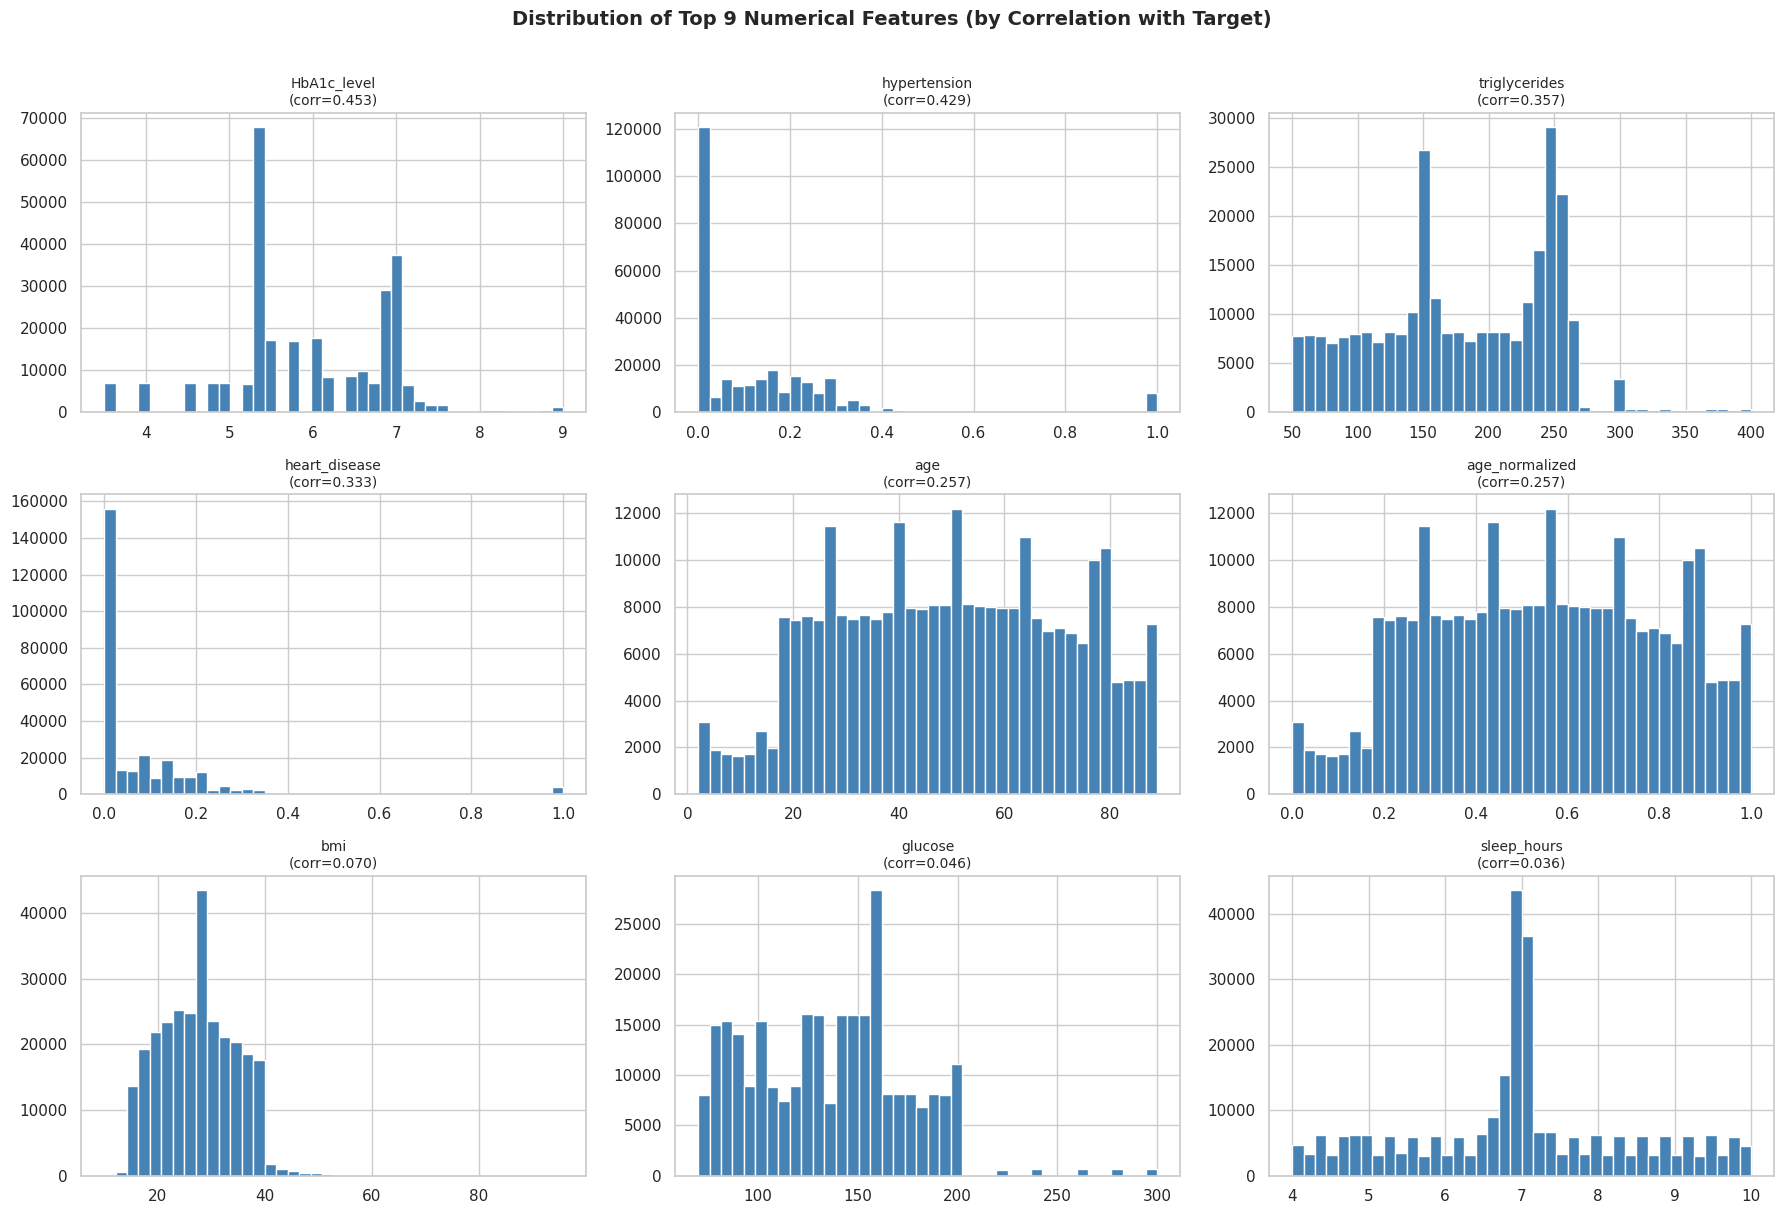


Categorical columns to plot (top 3 by correlation): ['diabetes', 'smoking', 'high_blood_pressure']


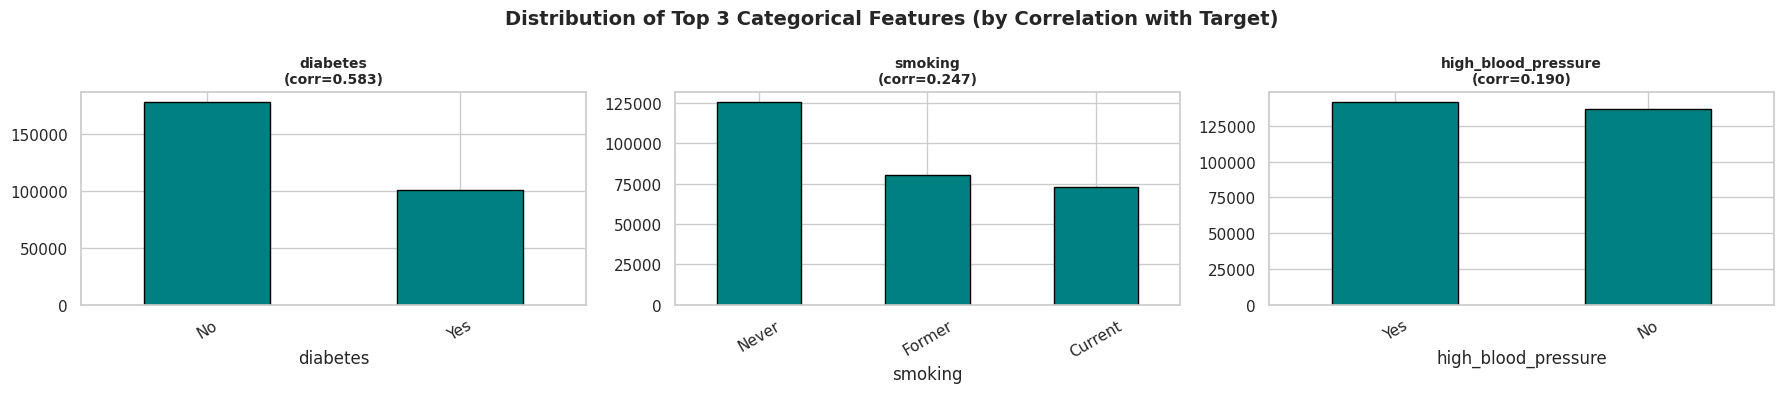

In [10]:
# ── Step 1: Compute correlation to select top features ───────────────
df_corr_eda = df.copy()

# Encode label for correlation
df_corr_eda['label_enc'] = (df_corr_eda['label'] == 'Abnormal').astype(int)

# Encode categoricals temporarily for correlation
cat_temp = df_corr_eda.select_dtypes(include='object').columns.tolist()
cat_temp = [c for c in cat_temp if c not in ['composite_key', 'source_dataset', 'disease_flags', 'label', 'sublabel']]
le_temp = {}
for col in cat_temp:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    df_corr_eda[col + '_enc'] = le.fit_transform(df_corr_eda[col].astype(str))
    le_temp[col] = le

# Numerical columns (nunique > 5)
num_cols_all = df_corr_eda.select_dtypes(include=[np.number]).columns.tolist()
plot_num_cols_all = [c for c in num_cols_all if df_corr_eda[c].nunique() > 5
                     and c not in ['label_enc']]

# Compute correlations for numerical
num_corr = df_corr_eda[plot_num_cols_all].corrwith(df_corr_eda['label_enc']).abs()
num_corr = num_corr.sort_values(ascending=False)
top9_num = num_corr.head(9).index.tolist()

# Compute correlations for categoricals (using encoded versions)
cat_enc_cols = [c + '_enc' for c in cat_temp if c + '_enc' in df_corr_eda.columns]
cat_corr = df_corr_eda[cat_enc_cols].corrwith(df_corr_eda['label_enc']).abs()
cat_corr.index = [c.replace('_enc', '') for c in cat_corr.index]
cat_corr = cat_corr.sort_values(ascending=False)
top3_cat = cat_corr.head(3).index.tolist()

print('=' * 55)
print('  CORRELATION-BASED FEATURE SELECTION (EDA)')
print('=' * 55)
print(f'\nTop 9 Numerical Features (by |corr| with label):')
for i, col in enumerate(top9_num, 1):
    print(f'  {i:2d}. {col:<30} corr = {num_corr[col]:.4f}')

print(f'\nTop 3 Categorical Features (by |corr| with label):')
for i, col in enumerate(top3_cat, 1):
    print(f'  {i:2d}. {col:<30} corr = {cat_corr[col]:.4f}')
print('=' * 55)

# ── Step 2: Numerical Features Distribution (top 9) ──────────────────
print(f'\nNumerical columns to plot (top 9 by correlation): {top9_num}')

ncols = 3
nrows = 3

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(top9_num):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\n(corr={num_corr[col]:.3f})', fontsize=10)
    axes[i].set_xlabel('')

for j in range(len(top9_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Top 9 Numerical Features (by Correlation with Target)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Step 3: Categorical Features Distribution (top 3) ────────────────
print(f'\nCategorical columns to plot (top 3 by correlation): {top3_cat}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes = axes.flatten()

for i, col in enumerate(top3_cat):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'{col}\n(corr={cat_corr[col]:.3f})', fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(top3_cat), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Top 3 Categorical Features (by Correlation with Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


##   6 — Full Correlation Heatmap (Numerical)

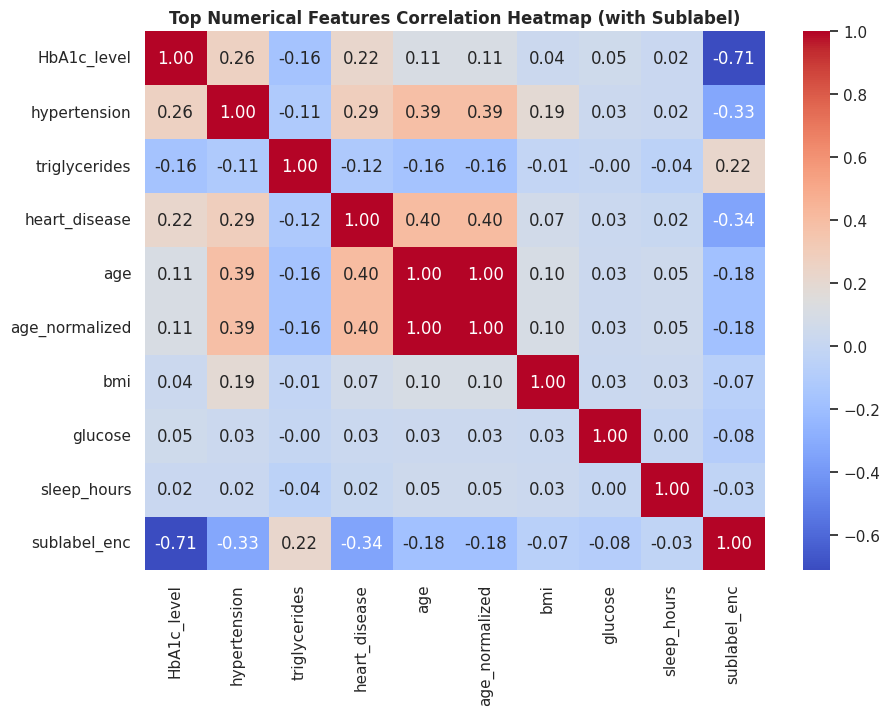

In [62]:
# Encode sublabel (target)
df_corr_eda['sublabel_enc'] = df_corr_eda['sublabel'].astype('category').cat.codes

# Add it to top numerical features
top_num_df = df_corr_eda[top9_num + ['sublabel_enc']]

# Correlation matrix
corr_matrix = top_num_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Top Numerical Features Correlation Heatmap (with Sublabel)", fontsize=12, fontweight='bold')
plt.show()

##   7 — EDA: Numerical Features by Label (Boxplots)

  OUTLIER ANALYSIS — TOP 9 NUMERICAL FEATURES
  HbA1c_level                    outliers:     0  (0.0%)
  hypertension                   outliers:  8060  (2.9%)
  triglycerides                  outliers:     0  (0.0%)
  heart_disease                  outliers: 10051  (3.6%)
  age                            outliers:     0  (0.0%)
  age_normalized                 outliers:     0  (0.0%)
  bmi                            outliers:  1005  (0.4%)
  glucose                        outliers:  2028  (0.7%)
  sleep_hours                    outliers:  1526  (0.5%)

  Columns WITH outliers (5): ['hypertension', 'heart_disease', 'bmi', 'glucose', 'sleep_hours']
  Columns WITHOUT outliers (4): ['HbA1c_level', 'triglycerides', 'age', 'age_normalized']

✅ Outliers treated using IQR capping (clip to [Q1-1.5*IQR, Q3+1.5*IQR])


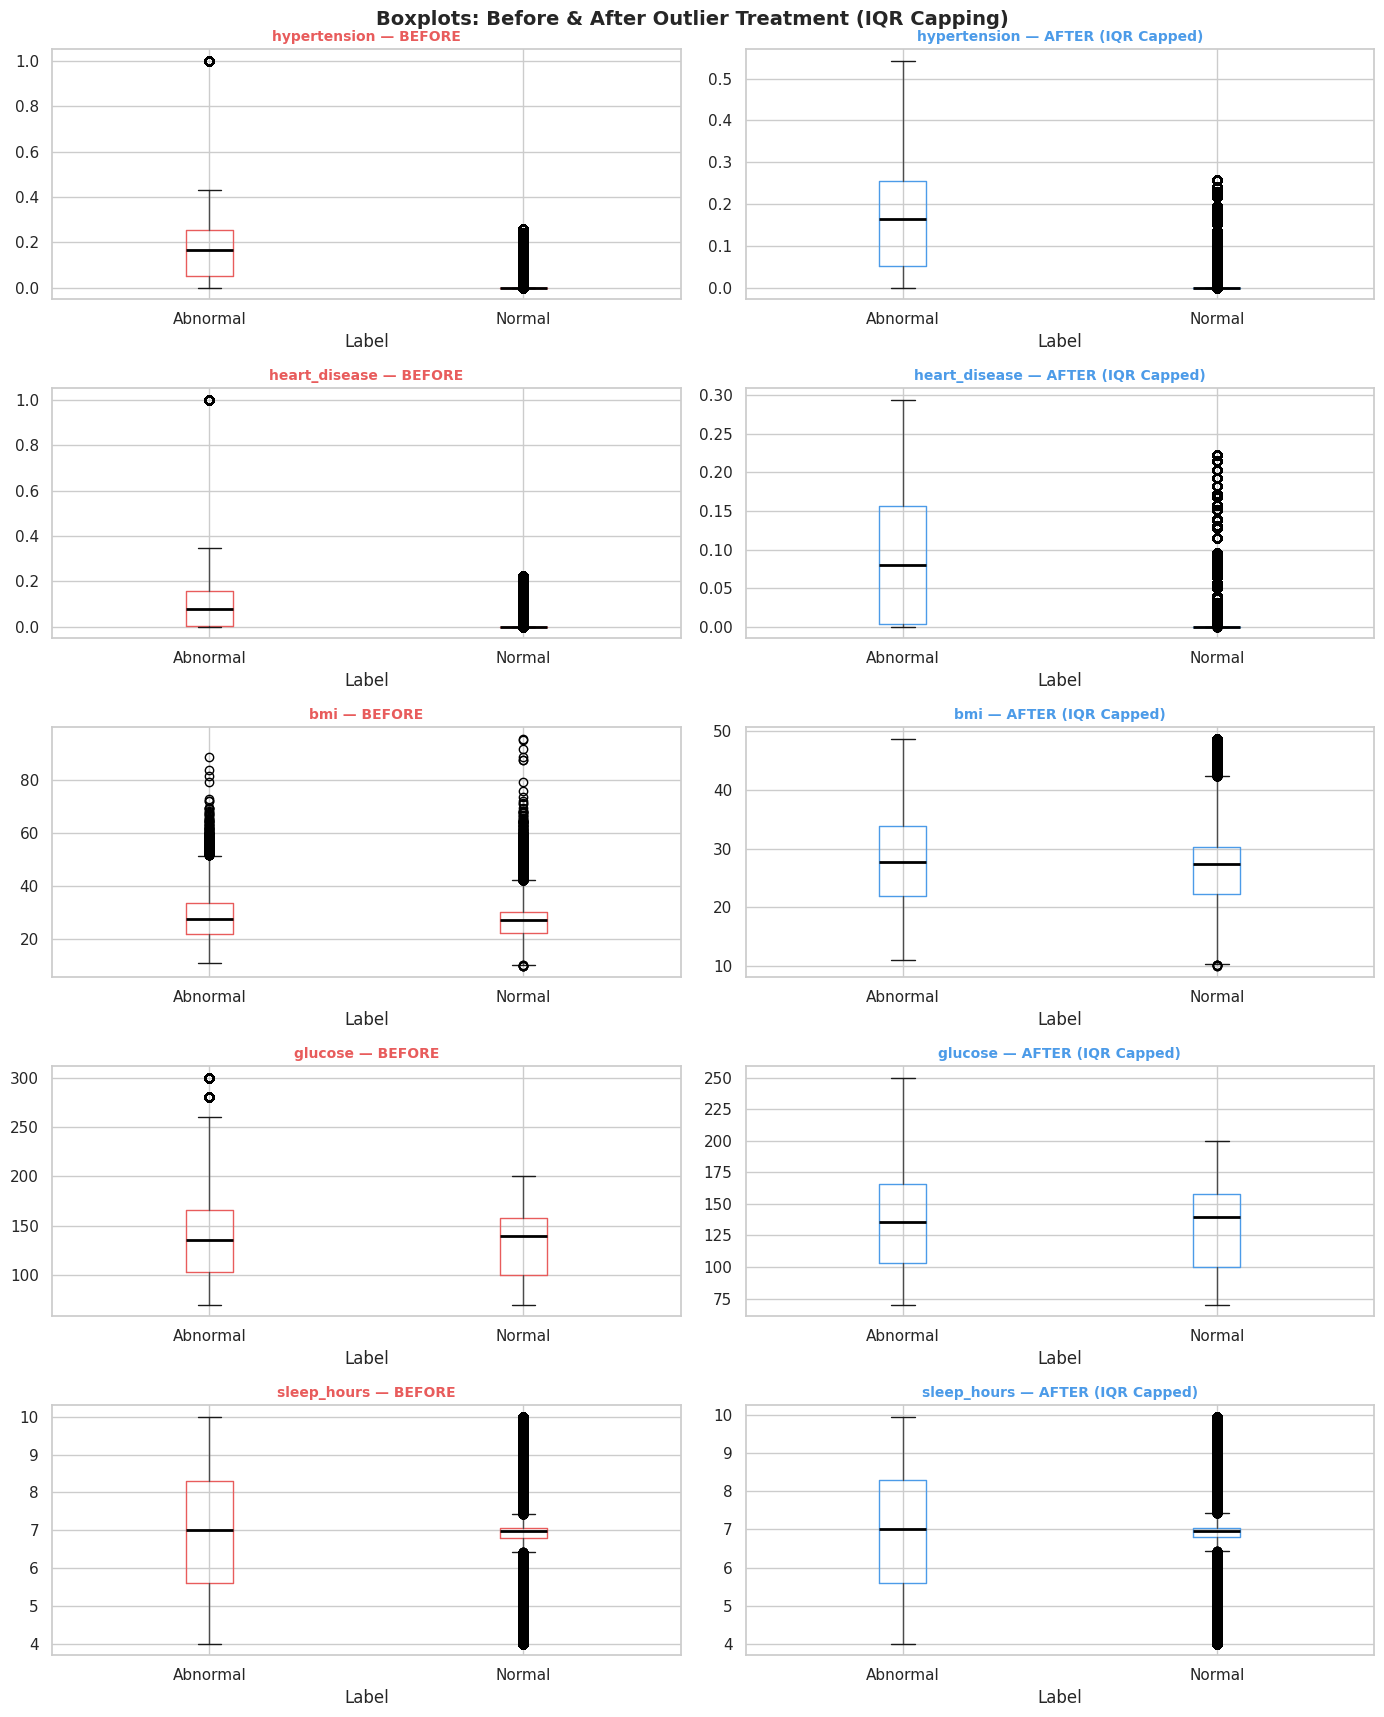

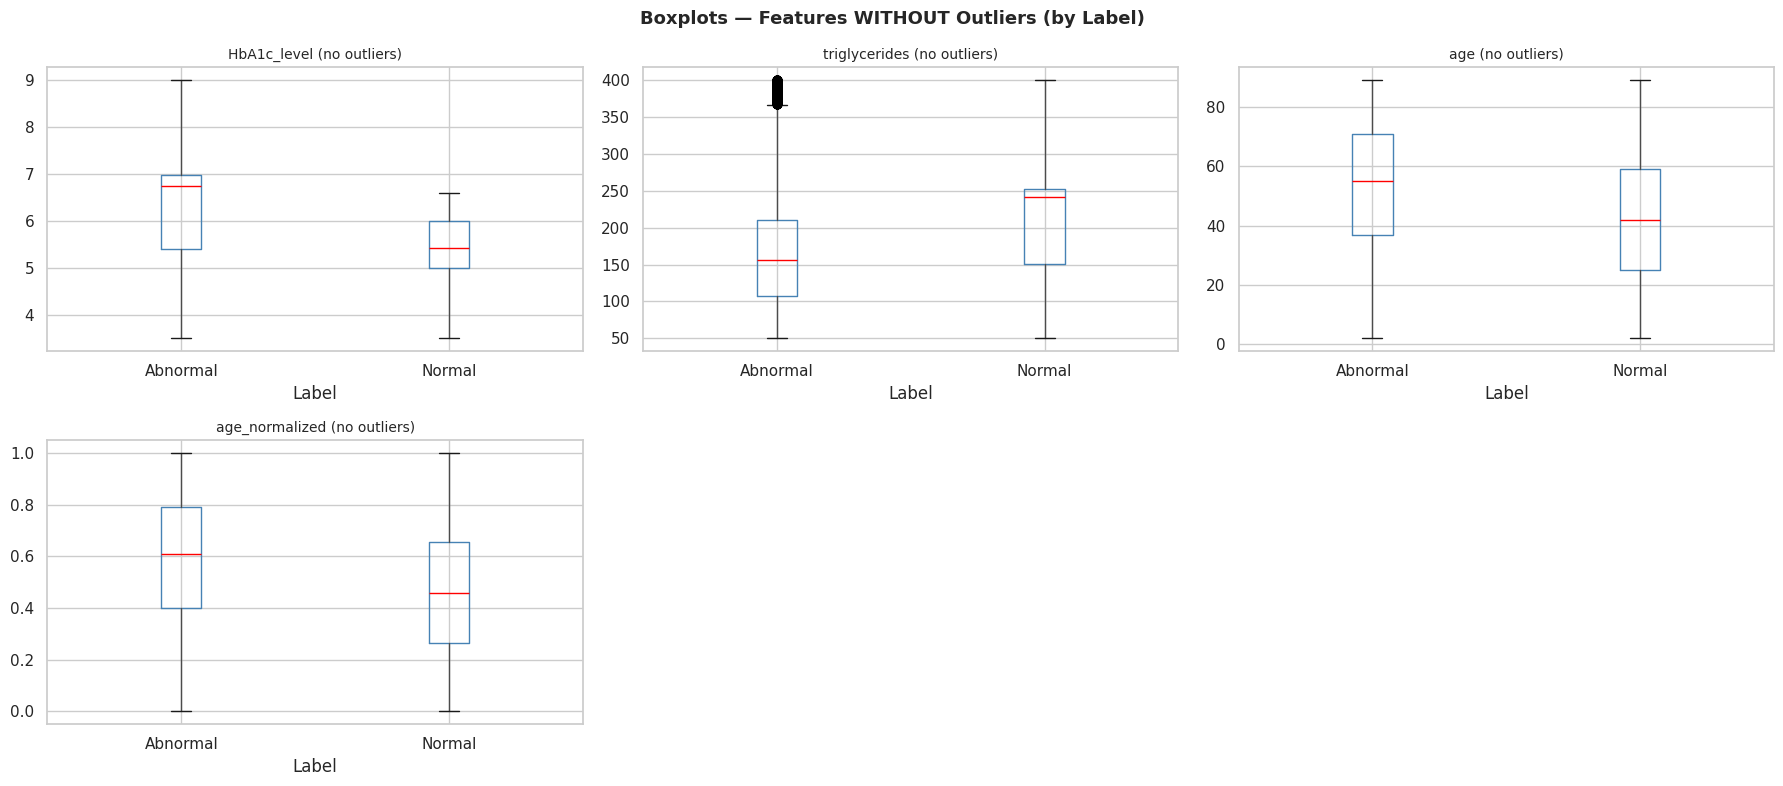

In [11]:
# ── Use top 9 numerical features from correlation (computed in Cell 5) ─
# top9_num was computed in Cell 5 — reuse it here

print('=' * 60)
print('  OUTLIER ANALYSIS — TOP 9 NUMERICAL FEATURES')
print('=' * 60)

# IQR-based outlier detection
outlier_summary = {}
for col in top9_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_pct = n_outliers / len(df) * 100
    outlier_summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'lower': lower, 'upper': upper,
                             'n_outliers': n_outliers, 'pct': outlier_pct}
    print(f'  {col:<30} outliers: {n_outliers:5d}  ({outlier_pct:.1f}%)')

cols_with_outliers = [c for c, v in outlier_summary.items() if v['n_outliers'] > 0]
cols_no_outliers   = [c for c in top9_num if c not in cols_with_outliers]

print(f'\n  Columns WITH outliers ({len(cols_with_outliers)}): {cols_with_outliers}')
print(f'  Columns WITHOUT outliers ({len(cols_no_outliers)}): {cols_no_outliers}')
print('=' * 60)

# ── Treat outliers using IQR capping ─────────────────────────────────
df_cleaned = df.copy()
for col in cols_with_outliers:
    lower = outlier_summary[col]['lower']
    upper = outlier_summary[col]['upper']
    df_cleaned[col] = df_cleaned[col].clip(lower=lower, upper=upper)

print('\n✅ Outliers treated using IQR capping (clip to [Q1-1.5*IQR, Q3+1.5*IQR])')

# ── Plot BEFORE & AFTER for columns that had outliers ────────────────
if cols_with_outliers:
    n = len(cols_with_outliers)
    ncols = 2   # before | after side by side per feature
    nrows = n

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
    if nrows == 1:
        axes = axes.reshape(1, 2)

    for i, col in enumerate(cols_with_outliers):
        # BEFORE
        df.boxplot(column=col, by='label', ax=axes[i, 0],
                   boxprops=dict(color='#E85C5C'),
                   medianprops=dict(color='black', linewidth=2))
        axes[i, 0].set_title(f'{col} — BEFORE', fontsize=10, fontweight='bold', color='#E85C5C')
        axes[i, 0].set_xlabel('Label')

        # AFTER
        df_cleaned.boxplot(column=col, by='label', ax=axes[i, 1],
                           boxprops=dict(color='#4C9BE8'),
                           medianprops=dict(color='black', linewidth=2))
        axes[i, 1].set_title(f'{col} — AFTER (IQR Capped)', fontsize=10, fontweight='bold', color='#4C9BE8')
        axes[i, 1].set_xlabel('Label')

    plt.suptitle('Boxplots: Before & After Outlier Treatment (IQR Capping)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('\nNo outliers detected in any of the top numerical features — no capping needed.')

# ── Boxplots for columns WITHOUT outliers (by label) ─────────────────
if cols_no_outliers:
    n = len(cols_no_outliers)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
    axes = axes.flatten()
    for i, col in enumerate(cols_no_outliers):
        df.boxplot(column=col, by='label', ax=axes[i],
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='red'))
        axes[i].set_title(f'{col} (no outliers)', fontsize=10)
        axes[i].set_xlabel('Label')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Boxplots — Features WITHOUT Outliers (by Label)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


##  8 — EDA: Categorical Features Distribution

<Figure size 800x600 with 0 Axes>

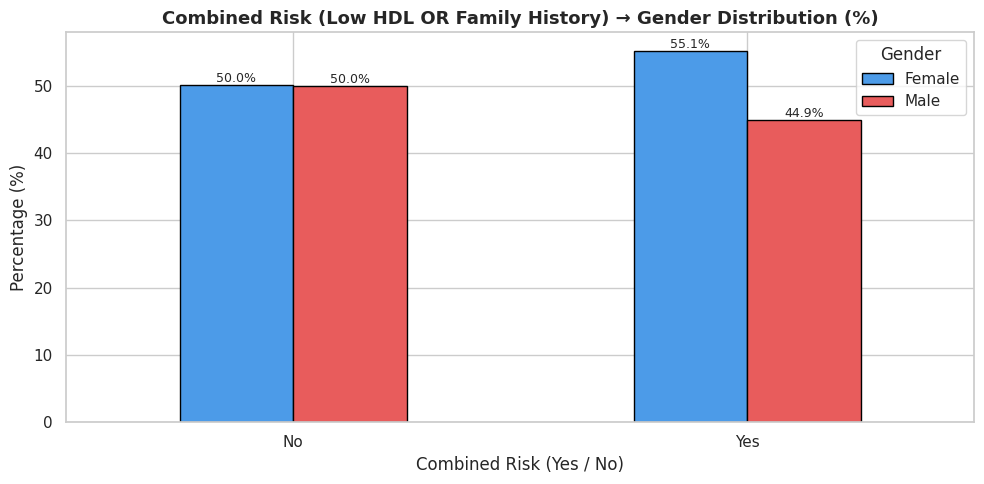

In [29]:
# ── All categorical columns ──────────────────────────────────────────
cat_cols_all = ['gender', 'smoking', 'physical_activity', 'family_history',
                'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol',
                'high_blood_pressure', 'sugar_consumption', 'education_level',
                'employment_status', 'age_level', 'bmi_level']
cat_cols_all = [c for c in cat_cols_all if c in df.columns]

# ─────────────────────────────────────────────────────────────────────
# PLOT 1: Binary Features Grouped by Gender
# low_hdl_cholesterol & family_history — both binary (Yes/No)
# X-axis: Gender | Hue: Yes/No value | Side-by-side bars per feature
# ─────────────────────────────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────
# NEW PLOT: Combined (Yes/No) → then split by Gender
# ─────────────────────────────────────────────────────────────
if all(col in df.columns for col in ['low_hdl_cholesterol', 'family_history', 'gender']):

    df_combined = df.copy()

    # Create combined binary feature
    df_combined['combined_risk'] = (
        (df_combined['low_hdl_cholesterol'].astype(str).str.lower() == 'yes') |
        (df_combined['family_history'].astype(str).str.lower() == 'yes')
    )

    # Convert True/False → Yes/No
    df_combined['combined_risk'] = df_combined['combined_risk'].map({True: 'Yes', False: 'No'})

    # Crosstab → نسبة الجندر داخل كل Yes/No
    crosstab = pd.crosstab(df_combined['combined_risk'], df_combined['gender'])
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0) * 100

    # Plot
    plt.figure(figsize=(8, 6))
    crosstab_pct.plot(kind='bar',
                      edgecolor='black',
                      color=['#4C9BE8', '#E85C5C'])  # Male / Female

    plt.title('Combined Risk (Low HDL OR Family History) → Gender Distribution (%)',
              fontsize=13, fontweight='bold')
    plt.xlabel('Combined Risk (Yes / No)')
    plt.ylabel('Percentage (%)')
    plt.legend(title='Gender')
    plt.xticks(rotation=0)

    # Add labels
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt='%.1f%%', fontsize=9)

    plt.tight_layout()
    plt.show()

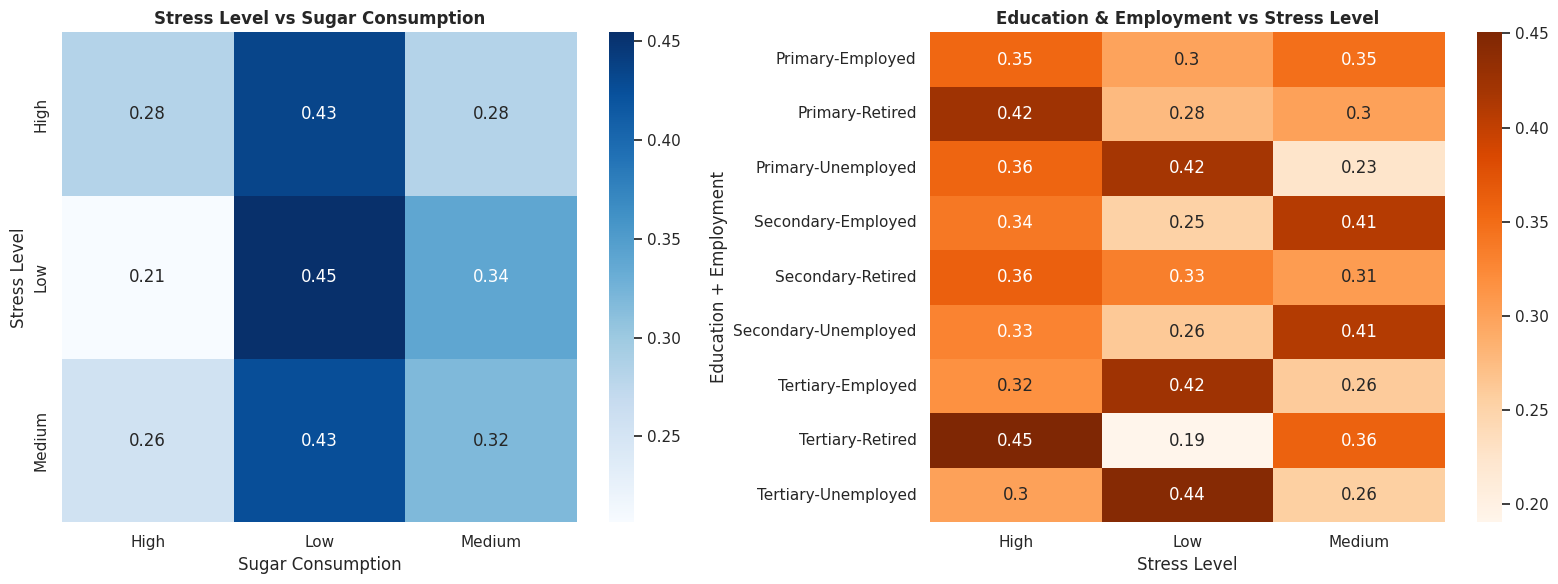

In [30]:
df_plot = df.copy()

fig, axes = plt.subplots(1, 2, figsize=(16,6))

# =========================
# 1) Stress vs Sugar
# =========================
stress_sugar = pd.crosstab(
    df_plot['stress_level'],
    df_plot['sugar_consumption'],
    normalize='index'   # نسب بدل أرقام
)

sns.heatmap(stress_sugar, annot=True, cmap='Blues', ax=axes[0])

axes[0].set_title('Stress Level vs Sugar Consumption', fontweight='bold')
axes[0].set_xlabel('Sugar Consumption')
axes[0].set_ylabel('Stress Level')


# =========================
# 2) Education + Employment vs Stress
# =========================
edu_emp_stress = pd.crosstab(
    [df_plot['education_level'], df_plot['employment_status']],
    df_plot['stress_level'],
    normalize='index'
)

sns.heatmap(edu_emp_stress, annot=True, cmap='Oranges', ax=axes[1])

axes[1].set_title('Education & Employment vs Stress Level', fontweight='bold')
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Education + Employment')

plt.tight_layout()
plt.show()

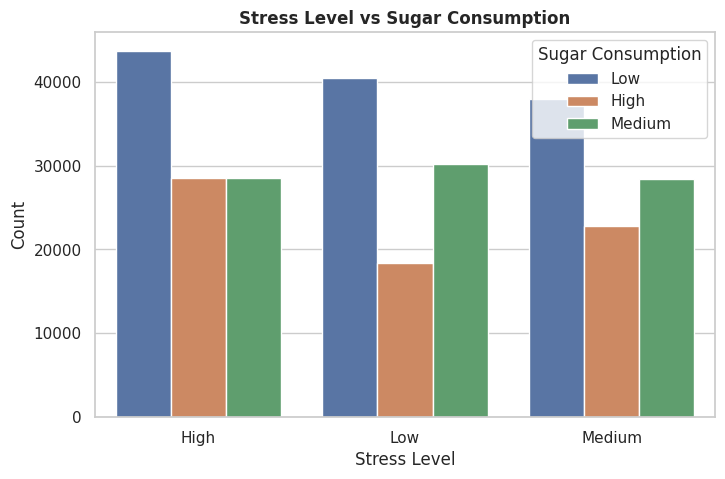

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='stress_level',
    hue='sugar_consumption'
)

plt.title('Stress Level vs Sugar Consumption', fontweight='bold')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.legend(title='Sugar Consumption')
plt.show()

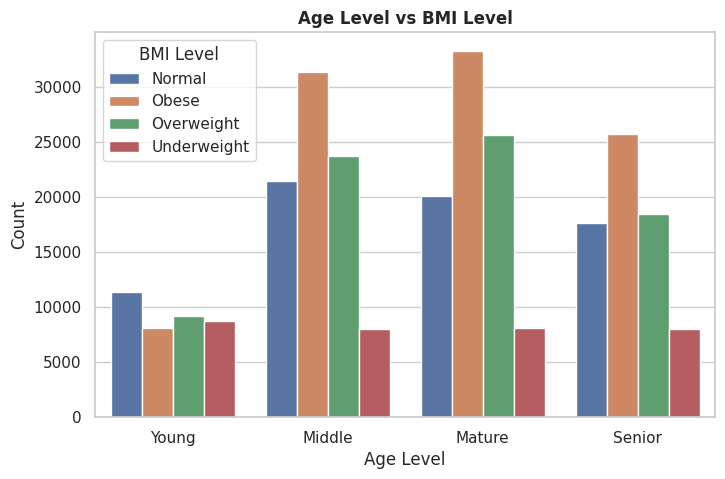

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='age_level',
    hue='bmi_level'
)

plt.title('Age Level vs BMI Level', fontweight='bold')
plt.xlabel('Age Level')
plt.ylabel('Count')
plt.legend(title='BMI Level')
plt.show()

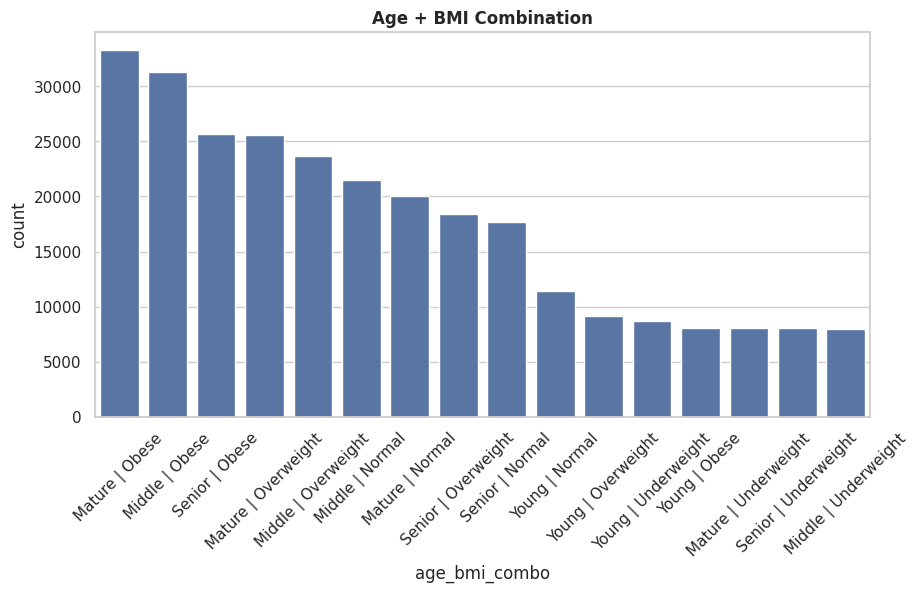

In [28]:
df['age_bmi_combo'] = df['age_level'] + " | " + df['bmi_level']

plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='age_bmi_combo',
    order=df['age_bmi_combo'].value_counts().index
)

plt.xticks(rotation=45)
plt.title('Age + BMI Combination', fontweight='bold')
plt.show()

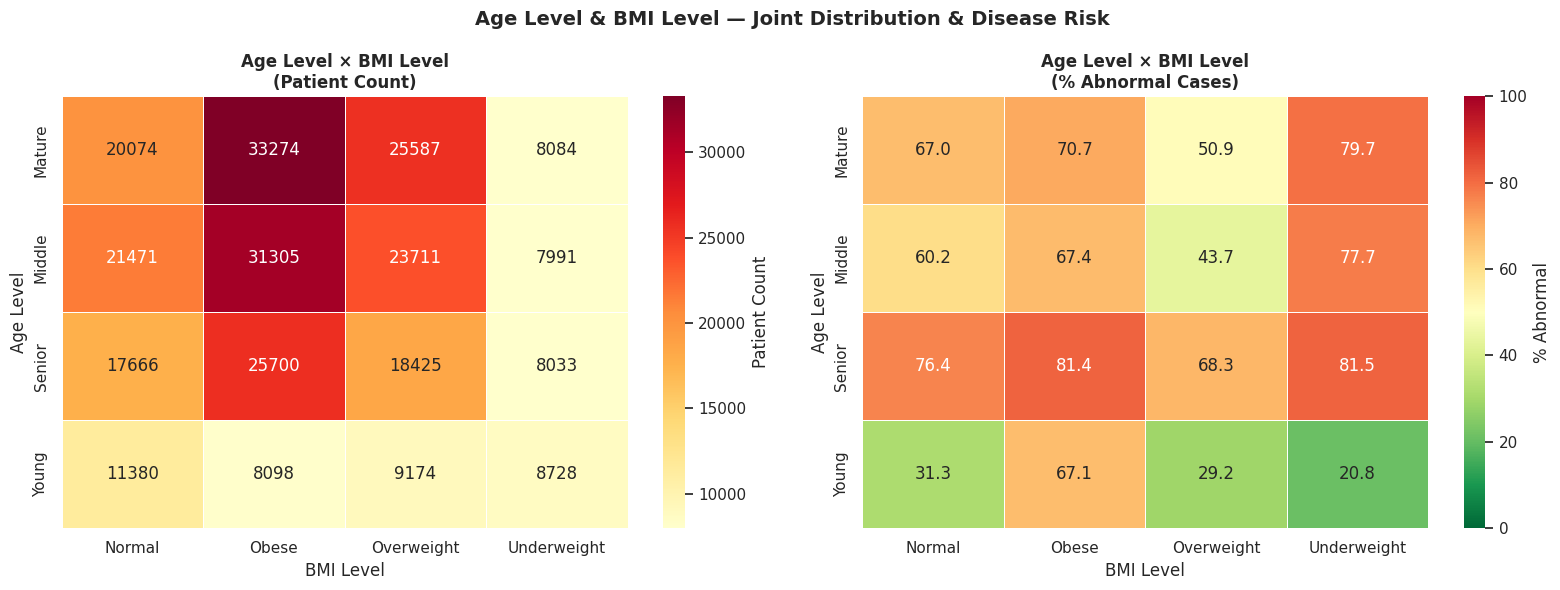

In [31]:
# ─────────────────────────────────────────────────────────────────────
# PLOT 3: age_level × bmi_level — Heatmap of count + label breakdown
# Show relationship between age group and BMI category
# ─────────────────────────────────────────────────────────────────────
if 'age_level' in df.columns and 'bmi_level' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap: count of patients per age_level × bmi_level
    pivot_count = pd.crosstab(df['age_level'], df['bmi_level'])
    sns.heatmap(pivot_count, annot=True, fmt='d', cmap='YlOrRd',
                ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Patient Count'})
    axes[0].set_title('Age Level × BMI Level\n(Patient Count)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('BMI Level')
    axes[0].set_ylabel('Age Level')

    # Heatmap: % Abnormal per age_level × bmi_level
    df_temp = df.copy()
    df_temp['is_abnormal'] = (df_temp['label'] == 'Abnormal').astype(int)
    pivot_abnormal = df_temp.groupby(['age_level', 'bmi_level'])['is_abnormal'].mean() * 100
    pivot_abnormal = pivot_abnormal.unstack(fill_value=0)
    sns.heatmap(pivot_abnormal, annot=True, fmt='.1f', cmap='RdYlGn_r',
                ax=axes[1], linewidths=0.5, cbar_kws={'label': '% Abnormal'},
                vmin=0, vmax=100)
    axes[1].set_title('Age Level × BMI Level\n(% Abnormal Cases)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('BMI Level')
    axes[1].set_ylabel('Age Level')

    plt.suptitle('Age Level & BMI Level — Joint Distribution & Disease Risk',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

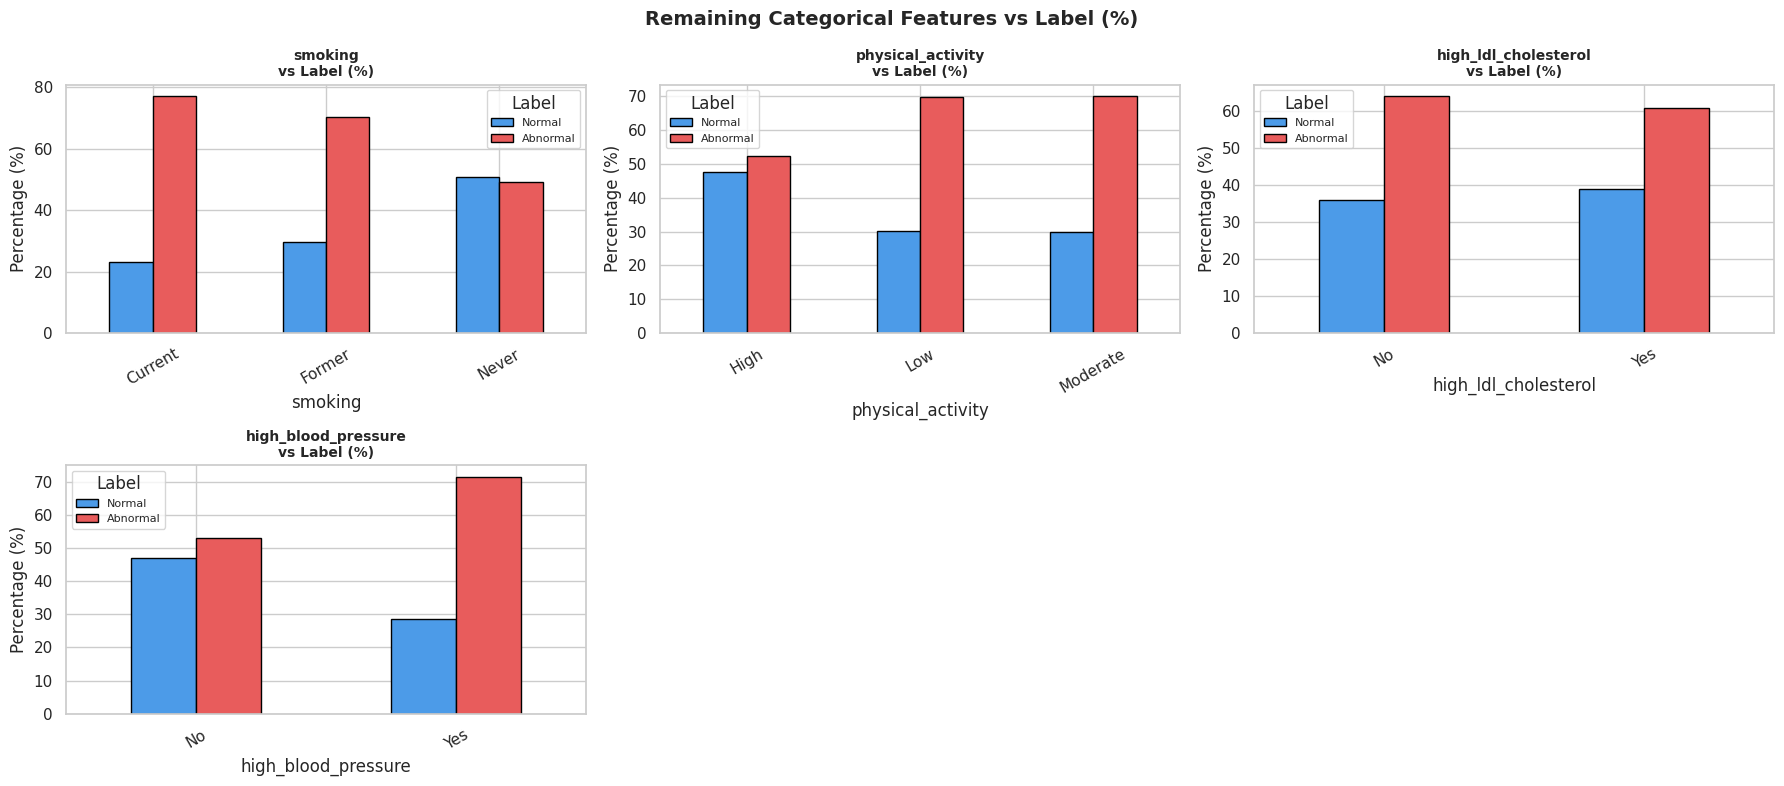

In [32]:
# ─────────────────────────────────────────────────────────────────────
# PLOT 4: Remaining categorical features — individual distribution bars
#          (smoking, physical_activity, high_ldl_cholesterol,
#           high_blood_pressure + any others not yet covered)
# ─────────────────────────────────────────────────────────────────────
covered = set(['low_hdl_cholesterol', 'family_history',
               'stress_level', 'sugar_consumption', 'education_level', 'employment_status',
               'age_level', 'bmi_level', 'gender'])
remaining_cat = [c for c in cat_cols_all if c not in covered]

if remaining_cat:
    n = len(remaining_cat)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(remaining_cat):
        if 'label' in df.columns:
            crosstab = pd.crosstab(df[col], df['label'], normalize='index') * 100
            for lbl in ['Normal', 'Abnormal']:
                if lbl not in crosstab.columns:
                    crosstab[lbl] = 0
            crosstab = crosstab[['Normal', 'Abnormal']]
            crosstab.plot(kind='bar', ax=axes[i], color=['#4C9BE8', '#E85C5C'],
                          edgecolor='black', rot=30)
            axes[i].set_title(f'{col}\nvs Label (%)', fontsize=10, fontweight='bold')
            axes[i].set_ylabel('Percentage (%)')
            axes[i].legend(title='Label', fontsize=8)
        else:
            counts = df[col].value_counts()
            counts.plot(kind='bar', ax=axes[i], color='teal', edgecolor='black')
            axes[i].set_title(col, fontsize=10, fontweight='bold')
            axes[i].tick_params(axis='x', rotation=30)

    for j in range(len(remaining_cat), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Remaining Categorical Features vs Label (%)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


##   9 — EDA: Categorical Features vs Label (Stacked)

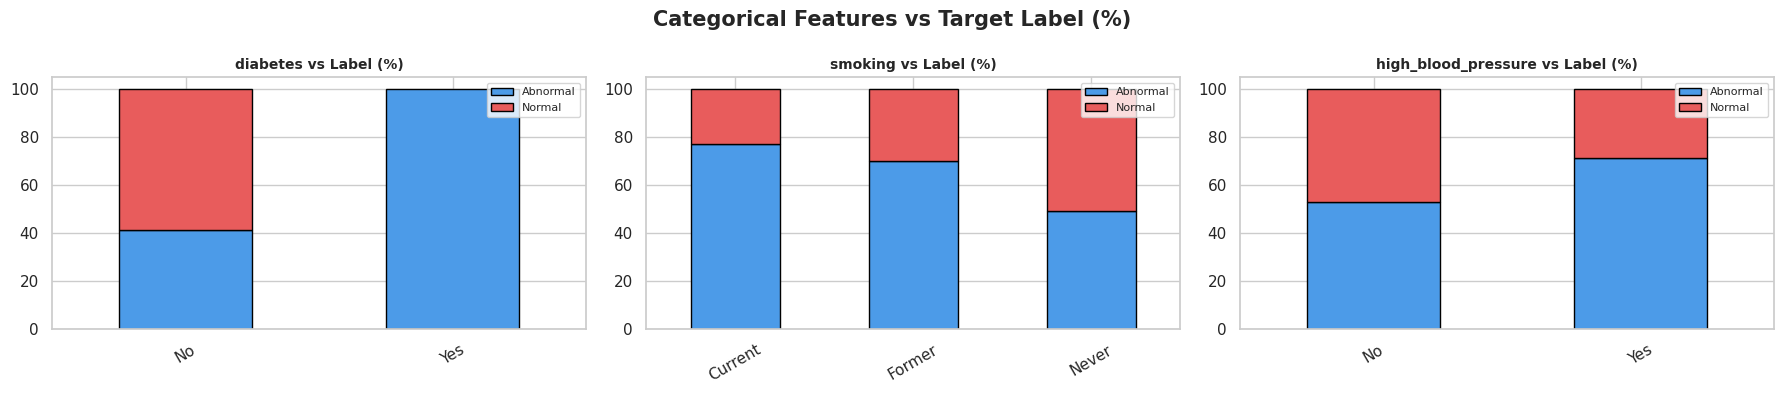

In [63]:
n = len(top3_cat)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(top3_cat):
    cross = pd.crosstab(df[col], df['label'], normalize='index') * 100
    cross.plot(kind='bar', stacked=True, ax=axes[i],
               color=['#4C9BE8', '#E85C5C'], edgecolor='black')
    axes[i].set_title(f'{col} vs Label (%)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(loc='upper right', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)


plt.suptitle('Categorical Features vs Target Label (%)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

##   10 — Correlation Analysis (Age & BMI Only — True Duplicates)

In [35]:
df_corr = df.copy()
# Correlation must be measured against the ACTUAL target = sublabel
le_sub_corr = LabelEncoder()
df_corr['sublabel_enc'] = le_sub_corr.fit_transform(df_corr['sublabel'].astype(str))

# Encode the categorical versions for fair comparison
le = LabelEncoder()
df_corr['age_level_enc'] = le.fit_transform(df_corr['age_level'].astype(str))
df_corr['bmi_level_enc'] = le.fit_transform(df_corr['bmi_level'].astype(str))

similar_groups = {
    'Age Group — same concept, 3 representations': [
        ('age',            'age'),
        ('age_normalized', 'age_normalized'),
        ('age_level',      'age_level_enc'),
    ],
    'BMI Group — same concept, 2 representations': [
        ('bmi',       'bmi'),
        ('bmi_level', 'bmi_level_enc'),
    ]
}

print('=' * 65)
print('  CORRELATION WITH TARGET — AGE & BMI GROUPS ONLY')
print('=' * 65)

corr_results = {}
for group_name, col_pairs in similar_groups.items():
    print(f'\n📌 {group_name}')
    group_corr = {}
    for display_name, col_key in col_pairs:
        c = abs(df_corr[col_key].corr(df_corr['sublabel_enc']))
        group_corr[display_name] = round(c, 4)
        print(f'   {display_name:<20} → |corr| = {c:.4f}')
    best = max(group_corr, key=group_corr.get)
    corr_results[group_name] = {'scores': group_corr, 'best': best}
    print(f'   ✅ Winner → {best}  (corr = {group_corr[best]:.4f})')

print('\n' + '=' * 65)
print('DECISION:')
print('  Age  group → keep:', corr_results[list(corr_results.keys())[0]]['best'])
print('  BMI  group → keep:', corr_results[list(corr_results.keys())[1]]['best'])

print('=' * 65)

  CORRELATION WITH TARGET — AGE & BMI GROUPS ONLY

📌 Age Group — same concept, 3 representations
   age                  → |corr| = 0.1776
   age_normalized       → |corr| = 0.1776
   age_level            → |corr| = 0.0649
   ✅ Winner → age  (corr = 0.1776)

📌 BMI Group — same concept, 2 representations
   bmi                  → |corr| = 0.0652
   bmi_level            → |corr| = 0.0413
   ✅ Winner → bmi  (corr = 0.0652)

DECISION:
  Age  group → keep: age
  BMI  group → keep: bmi


##   11 — Preprocessing: Drop Columns & Encode

In [36]:
# ─────────────────────────────────────────────────────────────────
# TARGET = sublabel  → Multi-class (N / DI / HY / HT / DI_HY / ...)
#
# sublabel  → KEEP (this is our y — separated in Feature Selection cell)
# label     → DROP  (derived FROM sublabel: Abnormal = any disease)
#                    keeping it would be leakage against sublabel
#
# disease_flags → DROP (direct numeric re-encoding of sublabel → leakage)
#
# diabetes, hypertension, heart_disease
#   → DROP (they directly BUILD sublabel; model sees them → trivial answer)
#
# composite_key, source_dataset → DROP (ID / metadata, no predictive value)
#
# age_normalized, age_level → DROP (redundant with raw age, lower corr)
# bmi_level                 → DROP (redundant with raw bmi, lower corr)
#
# cholesterol               → KEPT (corr=0.017 < threshold; Feature Selection handles it)
# low_hdl_cholesterol       → DROP (redundant with hdl numeric value)
# high_ldl_cholesterol      → DROP (redundant with ldl numeric value)
# blood_pressure            → DROP (redundant with systolic/diastolic)
# high_blood_pressure       → DROP (redundant with systolic/diastolic)
# ─────────────────────────────────────────────────────────────────
COLS_TO_DROP = [
    # ── ID / metadata ──────────────────────────────────────────
    'composite_key',
    'source_dataset',
    # ── Target leakage ─────────────────────────────────────────
    'label',
    'disease_flags',
    # ── Disease flags (build sublabel directly) ─────────────────
    'diabetes',
    'hypertension',
    'heart_disease',
    # ── Age/BMI duplicates ──────────────────────────────────────
    'age_normalized',
    'age_level',
    'bmi_level',
    # ── Cholesterol / BP redundant columns ──────────────────────
    'low_hdl_cholesterol',
    'high_ldl_cholesterol',
    'blood_pressure',
    'high_blood_pressure',
]

df_ml = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns]).copy()
print(f'Shape after dropping: {df_ml.shape}')
print(f'Remaining columns: {df_ml.columns.tolist()}')

Shape after dropping: (278701, 26)
Remaining columns: ['gender', 'smoking', 'age', 'bmi', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status', 'sublabel', 'age_bmi_combo']


##   12 — Preprocessing: Fix Mixed-Type Columns & Encode

In [37]:
# NOTE: diabetes, hypertension, heart_disease, label were already
# dropped in Cell 11. sublabel is our target — encode it here.

# Encode target (sublabel → multi-class integer)
le_target = LabelEncoder()
df_ml['sublabel'] = le_target.fit_transform(df_ml['sublabel'].astype(str))
print('Target classes (sublabel):', list(le_target.classes_))
print('Encoded as             :', list(range(len(le_target.classes_))))

# Encode all remaining categorical columns using LabelEncoder
remaining_cats = df_ml.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {remaining_cats}')

label_encoders = {}
for col in remaining_cats:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    label_encoders[col] = le

print(f'\nShape after encoding: {df_ml.shape}')
print(f'Target (sublabel) distribution:\n{df_ml["sublabel"].value_counts()}')
df_ml.head()

Target classes (sublabel): ['DI', 'DI_HT', 'DI_HT_HY', 'DI_HY', 'HT', 'HT_HY', 'HY', 'N']
Encoded as             : [0, 1, 2, 3, 4, 5, 6, 7]
Categorical columns to encode: ['gender', 'smoking', 'physical_activity', 'family_history', 'stress_level', 'sugar_consumption', 'education_level', 'employment_status', 'age_bmi_combo']

Shape after encoding: (278701, 26)
Target (sublabel) distribution:
sublabel
7    104648
6     69787
3     66472
0     31903
4      2583
1      1398
5      1065
2       845
Name: count, dtype: int64


,gender,smoking,age,bmi,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,physical_activity,...,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,sublabel,age_bmi_combo
0,0,2,9,19.20,5.8,158.0,214.703704,6.864403,246.703704,0,...,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,0,1,7,12
1,0,2,3,22.55,6.6,159.0,214.703704,6.864403,246.703704,0,...,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,0,1,7,12
2,0,2,3,22.89,4.0,126.0,214.703704,6.864403,246.703704,0,...,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,0,1,7,12
3,0,2,3,23.12,6.2,85.0,214.703704,6.864403,246.703704,0,...,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,0,1,7,12
4,0,2,4,19.61,5.7,155.0,214.703704,6.864403,246.703704,0,...,89.539936,14.777636,8.685304,74.329073,65.651757,129.220447,0,1,7,12


##   13 — Feature Engineering

In [38]:
# ── New engineered features ──────────────────────────────────────────

# 1. Metabolic Risk Score: combines glucose, HbA1c, bmi
df_ml['metabolic_risk'] = (
    df_ml['glucose'] / df_ml['glucose'].max() +
    df_ml['HbA1c_level'] / df_ml['HbA1c_level'].max() +
    df_ml['bmi'] / df_ml['bmi'].max()
)

# 2. Cardiovascular Risk Score: systolic_bp, diastolic_bp, triglycerides, crp_level
df_ml['cardio_risk'] = (
    df_ml['systolic_bp'] / df_ml['systolic_bp'].max() +
    df_ml['diastolic_bp'] / df_ml['diastolic_bp'].max() +
    df_ml['triglycerides'] / df_ml['triglycerides'].max() +
    df_ml['crp_level'] / df_ml['crp_level'].max()
)

# 3. Lipid Ratio: ldl / hdl (cardiovascular risk indicator)
df_ml['ldl_hdl_ratio'] = df_ml['ldl'] / (df_ml['hdl'] + 1e-6)

# 4. Pulse Pressure: systolic - diastolic
df_ml['pulse_pressure'] = df_ml['systolic_bp'] - df_ml['diastolic_bp']

# 5. Lifestyle Risk (categorical): smoking + physical_activity + stress_level
#    These are already encoded; we add them as a sum-based score
df_ml['lifestyle_risk'] = df_ml['smoking'] + df_ml['physical_activity'] + df_ml['stress_level']

print(f'Shape after feature engineering: {df_ml.shape}')
print('New columns added: metabolic_risk, cardio_risk, ldl_hdl_ratio, pulse_pressure, lifestyle_risk')
df_ml[['metabolic_risk','cardio_risk','ldl_hdl_ratio','pulse_pressure','lifestyle_risk']].describe()

Shape after feature engineering: (278701, 31)
New columns added: metabolic_risk, cardio_risk, ldl_hdl_ratio, pulse_pressure, lifestyle_risk


,metabolic_risk,cardio_risk,ldl_hdl_ratio,pulse_pressure,lifestyle_risk
count,278701.000000,278701.000000,278701.000000,278701.000000,278701.000000
mean,1.399522,2.448471,2.158534,44.932549,3.012221
std,0.188745,0.244000,0.821961,24.743326,1.415350
min,0.785768,1.274838,0.707071,-29.000000,0.000000
25%,1.268422,2.297085,1.800000,36.000000,2.000000
50%,1.397290,2.467090,2.010907,44.819709,3.000000
75%,1.520559,2.628631,2.254545,54.000000,4.000000
max,2.705754,3.498473,6.300000,119.000000,6.000000


##   14 — Feature Selection (Correlation-based + Top-N)

Top 20 features by |correlation| with target:
HbA1c_level           0.712279
metabolic_risk        0.482262
triglycerides         0.219243
age                   0.177594
cardio_risk           0.163410
smoking               0.160582
physical_activity     0.092148
glucose               0.084323
education_level       0.076097
family_history        0.072045
age_bmi_combo         0.071969
bmi                   0.065240
crp_level             0.055202
sugar_consumption     0.054061
ldl_hdl_ratio         0.051498
gender                0.046527
stress_level          0.034929
homocysteine_level    0.031203
employment_status     0.029286
sleep_hours           0.025487
dtype: float64


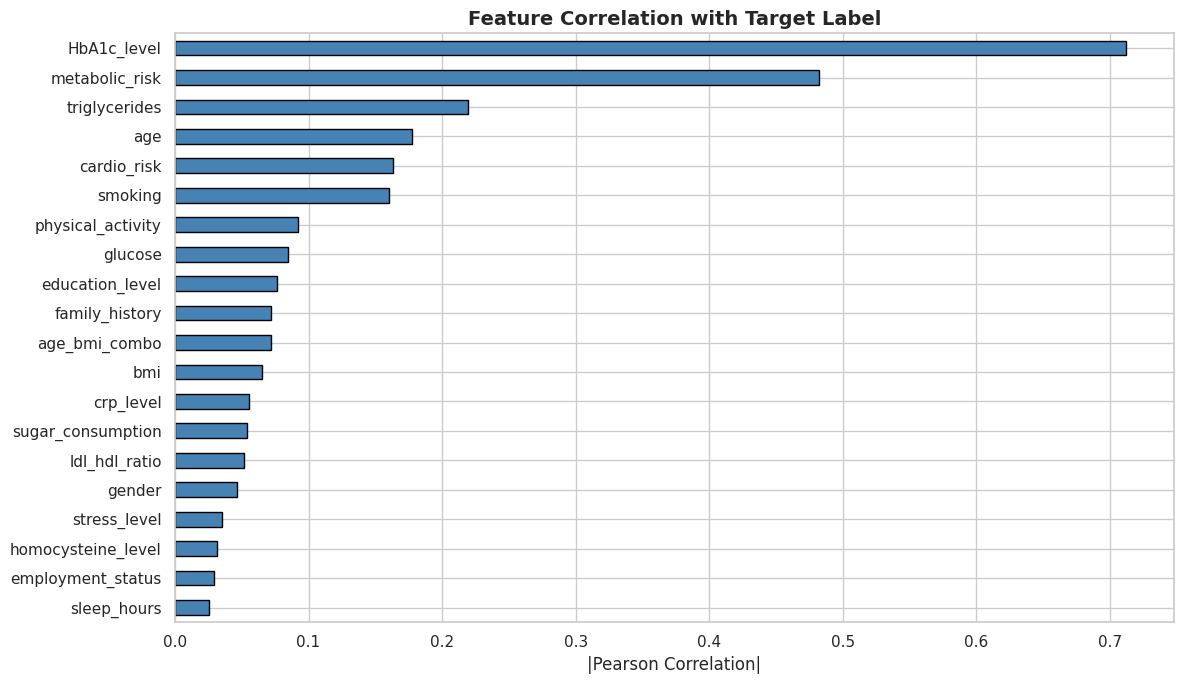


Features selected (|corr| >= 0.03): 18
['HbA1c_level', 'metabolic_risk', 'triglycerides', 'age', 'cardio_risk', 'smoking', 'physical_activity', 'glucose', 'education_level', 'family_history', 'age_bmi_combo', 'bmi', 'crp_level', 'sugar_consumption', 'ldl_hdl_ratio', 'gender', 'stress_level', 'homocysteine_level']


In [43]:
# ── Pearson correlation with target ─────────────────────────────────
# IMPORTANT: Feature selection is done on the FULL dataset here to
# decide WHICH features to keep (column names only).
# The actual correlation threshold is applied before splitting,
# but we use corrwith on full data just to rank features.
# This is acceptable because we are only selecting feature names,
# not learning any parameters from test data.
X_all = df_ml.drop('sublabel', axis=1)
y = df_ml['sublabel']

corr_with_target = X_all.corrwith(y).abs().sort_values(ascending=False)

print('Top 20 features by |correlation| with target:')
print(corr_with_target.head(20))

# Visualize
plt.figure(figsize=(12, 7))
corr_with_target.head(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Feature Correlation with Target Label', fontsize=14, fontweight='bold')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()

# Select features with correlation > threshold
CORR_THRESHOLD = 0.03
selected_features = corr_with_target[corr_with_target >= CORR_THRESHOLD].index.tolist()
print(f'\nFeatures selected (|corr| >= {CORR_THRESHOLD}): {len(selected_features)}')
print(selected_features)

X = X_all[selected_features].copy()


##   15 — Train/Test Split & SMOTE (Multi-class)

Train size : (222960, 18)
Test  size : (55741, 18)

Class distribution BEFORE SMOTE:
sublabel
DI_HT_HY      676
HT_HY         852
DI_HT        1118
HT           2066
DI          25522
DI_HY       53178
HY          55830
N           83718
Name: count, dtype: int64

Max/Min class ratio: 123.8x  ← severe imbalance

⚠️  Severe imbalance detected (126x ratio) — applying SMOTE...

Class distribution AFTER SMOTE:
sublabel
DI_HY       83718
HY          83718
HT          83718
N           83718
DI          83718
DI_HT       83718
HT_HY       83718
DI_HT_HY    83718
Name: count, dtype: int64

Dataset size: 222,960 → 669,744 rows
Max/Min class ratio after SMOTE: 1.0x  ✅


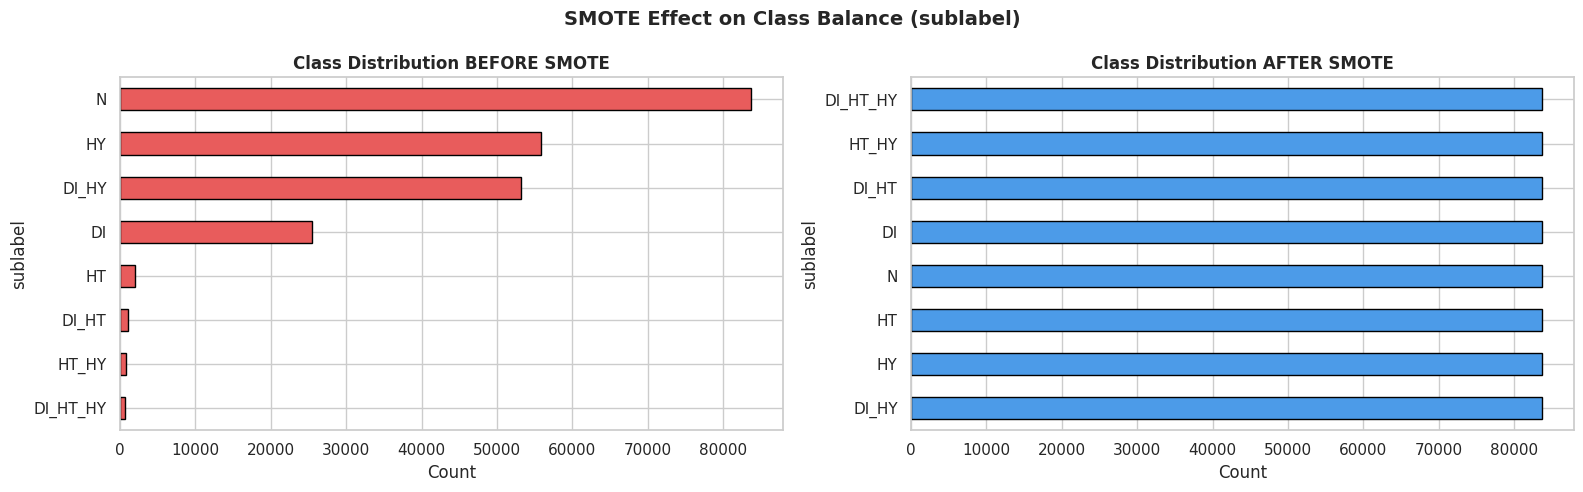


✅ SMOTE applied and features scaled successfully!


In [44]:
# ── Train / Test Split ────────────────────────────────────────────────
# stratify=y ensures every class (all 8 sublabels) is represented
# proportionally in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test  size : {X_test.shape}')

# ── Visualize class imbalance BEFORE SMOTE ────────────────────────────
counts_before = pd.Series(y_train).map(
    dict(enumerate(le_target.classes_))
).value_counts().sort_values()

print(f'\nClass distribution BEFORE SMOTE:')
print(counts_before)
print(f'\nMax/Min class ratio: {counts_before.max() / counts_before.min():.1f}x  ← severe imbalance')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
counts_before.plot(kind='barh', ax=axes[0], color='#E85C5C', edgecolor='black')
axes[0].set_title('Class Distribution BEFORE SMOTE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Count')

# ── Apply SMOTE (works natively with multi-class) ─────────────────────
# SMOTE oversamples each minority class using KNN interpolation.
# It handles multi-class automatically — generates synthetic samples
# for each class that has fewer samples than the majority class.
print('\n⚠️  Severe imbalance detected (126x ratio) — applying SMOTE...')
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res_np, y_train_res = smote.fit_resample(X_train, y_train)
# Convert back to DataFrame to preserve column names (needed for Feature Importance)
X_train_res = pd.DataFrame(X_train_res_np, columns=X_train.columns)
y_train_res = pd.Series(y_train_res)

# ── Visualize AFTER SMOTE ─────────────────────────────────────────────
counts_after = pd.Series(y_train_res).map(
    dict(enumerate(le_target.classes_))
).value_counts().sort_values()

print(f'\nClass distribution AFTER SMOTE:')
print(counts_after)
print(f'\nDataset size: {X_train.shape[0]:,} → {X_train_res.shape[0]:,} rows')
print(f'Max/Min class ratio after SMOTE: {counts_after.max() / counts_after.min():.1f}x  ✅')

counts_after.plot(kind='barh', ax=axes[1], color='#4C9BE8', edgecolor='black')
axes[1].set_title('Class Distribution AFTER SMOTE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Count')

plt.suptitle('SMOTE Effect on Class Balance (sublabel)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Scale features (required for Logistic Regression & SVM) ──────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)  # numpy array — OK for LR & SVM
X_test_scaled  = scaler.transform(X_test)           # numpy array — OK for LR & SVM
print('\n✅ SMOTE applied and features scaled successfully!')

##   16 — Model Training (5 Models)

In [45]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=500, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    "LinearSVC (SVM)": CalibratedClassifierCV(
        LinearSVC(max_iter=3000, C=1.0, class_weight='balanced', random_state=42), cv=3
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, verbose=-1),
}

# ── Train each model ─────────────────────────────────────────────────
trained_models = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    # LR and SVM use scaled data; tree-based use raw
    # LinearSVC (SVM) and Logistic Regression need scaled data
    if name in ['Logistic Regression', 'LinearSVC (SVM)']:
        model.fit(X_train_scaled, y_train_res)
    else:
        model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print('✅ Done')

print('\n✅ All models trained successfully!')

Training Logistic Regression... ✅ Done
Training Random Forest... ✅ Done
Training LinearSVC (SVM)... ✅ Done
Training XGBoost... ✅ Done
Training LightGBM... ✅ Done

✅ All models trained successfully!


##   17 — Evaluation Metrics

In [46]:
results = []

# sublabel class names for display
class_names = list(le_target.classes_)

for name, model in trained_models.items():
    X_eval = X_test_scaled if name in ['Logistic Regression', 'LinearSVC (SVM)'] else X_test

    y_pred  = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)

    # ROC-AUC for multi-class → OvR weighted
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score':  round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'ROC-AUC':   round(roc_auc, 4),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n=== Model Evaluation Results (Multi-class: weighted avg) ===')
print(results_df.to_string(index=False))


=== Model Evaluation Results (Multi-class: weighted avg) ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
           LightGBM    0.7444     0.7582  0.7444    0.7250   0.9254
            XGBoost    0.7331     0.7640  0.7331    0.7179   0.9231
      Random Forest    0.6993     0.7735  0.6993    0.6963   0.9139
Logistic Regression    0.4868     0.6196  0.4868    0.5382   0.8606
    LinearSVC (SVM)    0.4907     0.6141  0.4907    0.5378   0.8334


##   18 — Confusion Matrices

<Figure size 600x500 with 0 Axes>

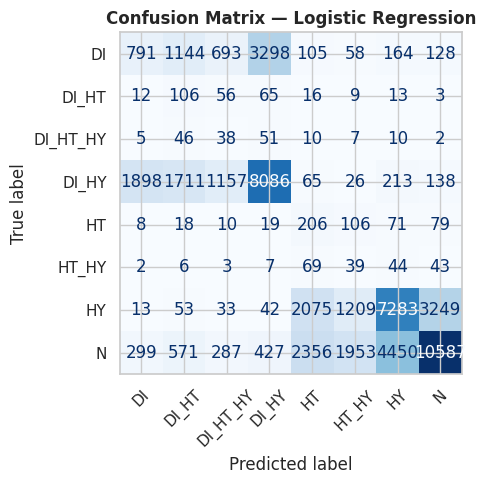

<Figure size 600x500 with 0 Axes>

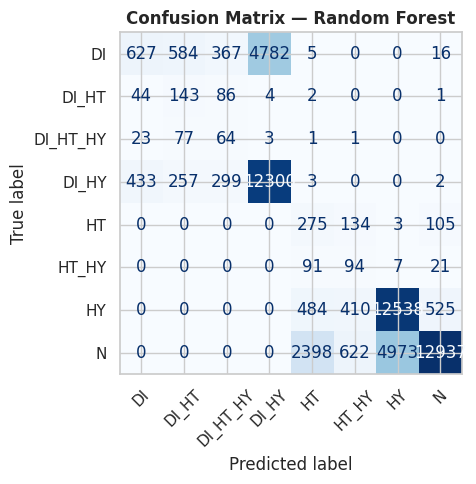

<Figure size 600x500 with 0 Axes>

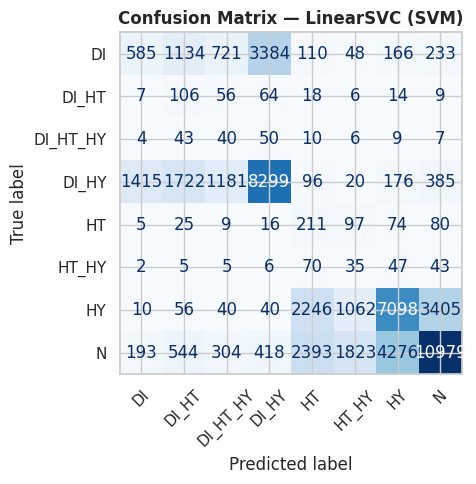

<Figure size 600x500 with 0 Axes>

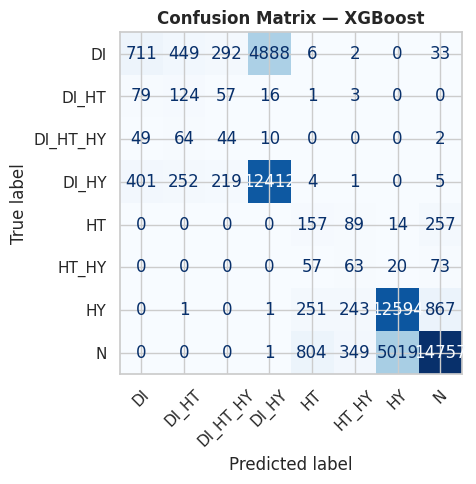

<Figure size 600x500 with 0 Axes>

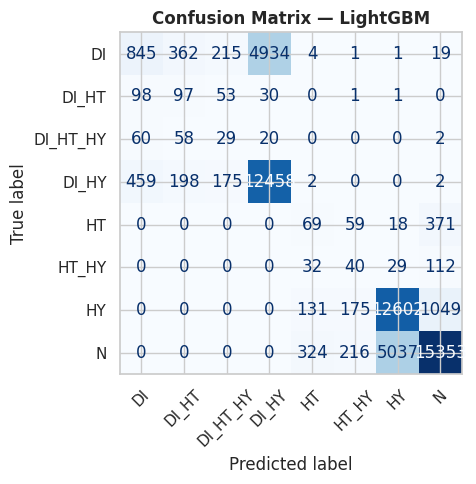

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in trained_models.items():

    X_eval = X_test_scaled if name in ['Logistic Regression', 'LinearSVC (SVM)'] else X_test
    y_pred = model.predict(X_eval)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))  # 🔥 Figure منفصلة لكل موديل

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=class_names)

    disp.plot(cmap='Blues', colorbar=False)

    plt.title(f'Confusion Matrix — {name}', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

##   19 — ROC Curves

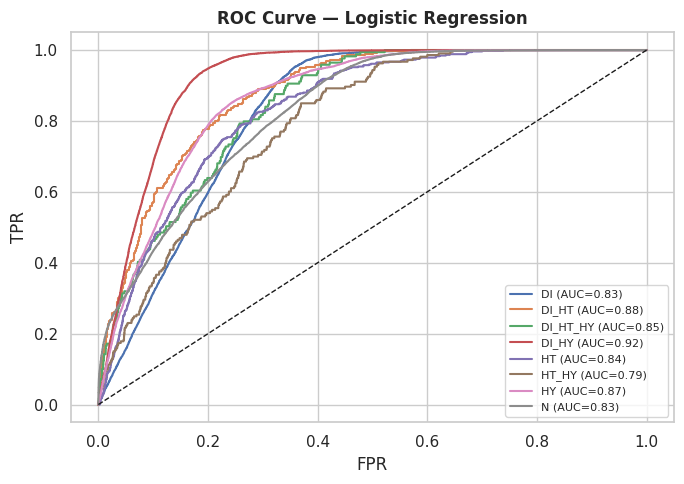

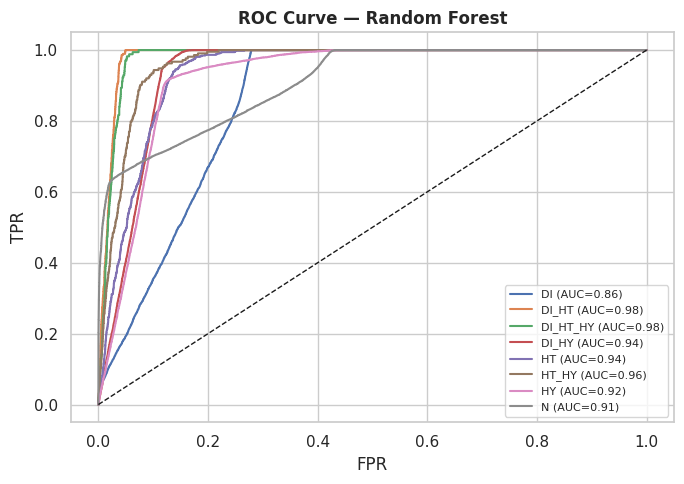

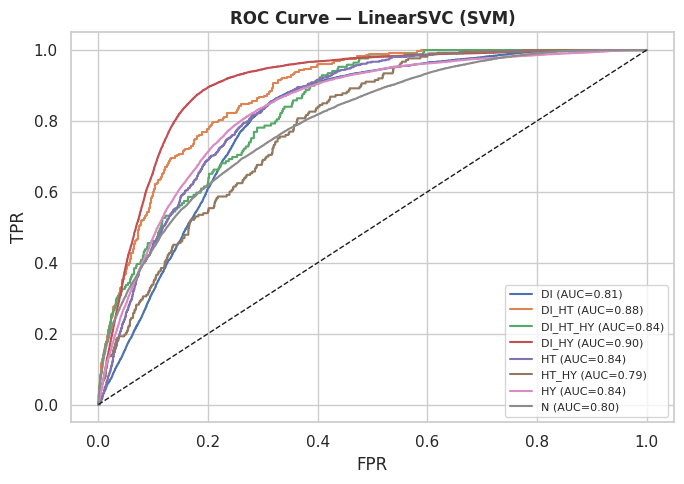

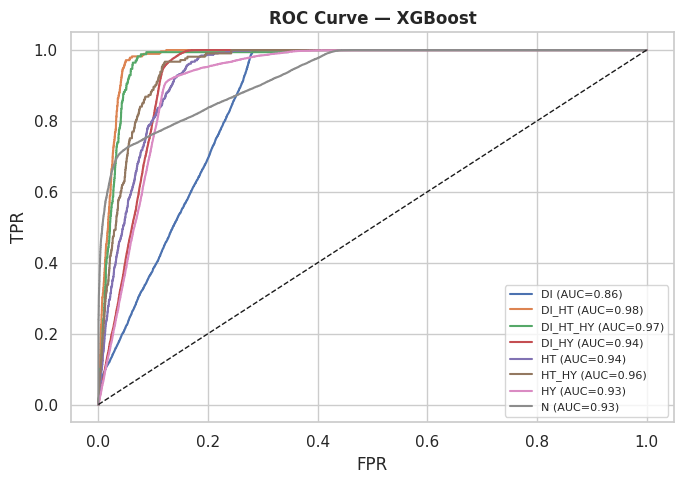

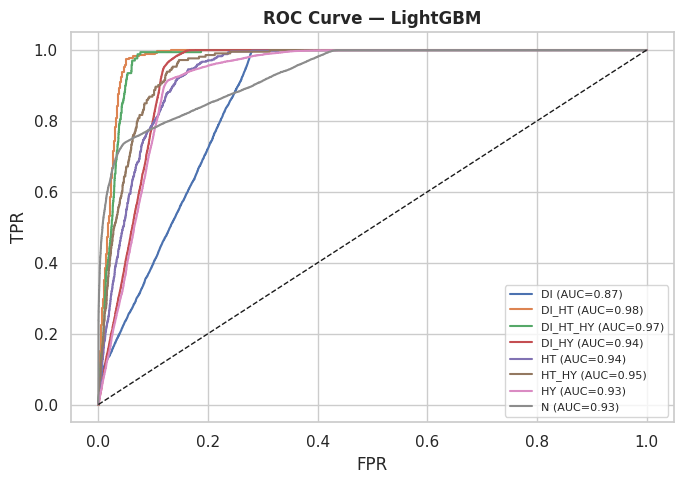

In [55]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for (name, model), color in zip(trained_models.items(), colors):

    plt.figure(figsize=(7, 5))  # 🔥 Figure جديدة لكل موديل

    X_eval = X_test_scaled if name in ['Logistic Regression', 'LinearSVC (SVM)'] else X_test

    y_proba = model.predict_proba(X_eval)

    for j, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_proba[:, j])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=1.5, label=f'{cls_name} (AUC={roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title(f'ROC Curve — {name}', fontsize=12, fontweight='bold')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.show()

##   20 — Model Comparison Bar Chart

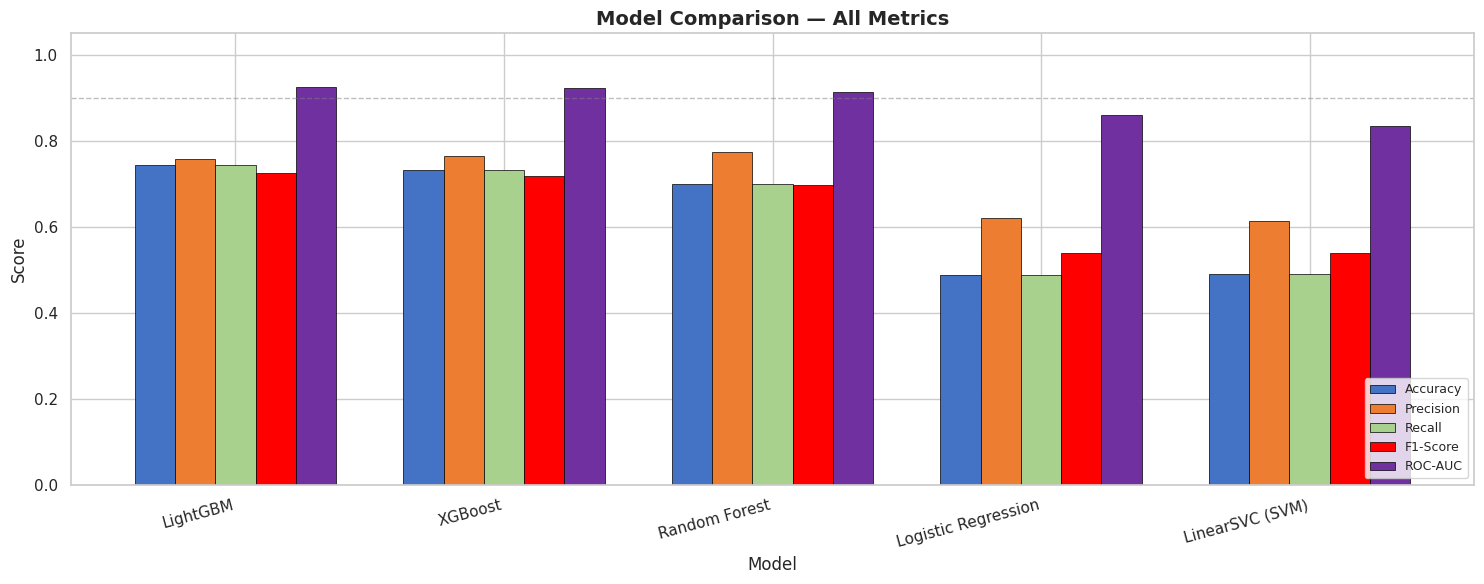

In [49]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(15, 6))
colors = ['#4472C4','#ED7D31','#A9D18E','#FF0000','#7030A0']

for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, results_df[metric], width,
                  label=metric, color=colors[i], edgecolor='black', linewidth=0.5)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=9)
ax.axhline(y=0.9, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.tight_layout()
plt.show()

##   21 — Feature Importance (Tree-based Models)

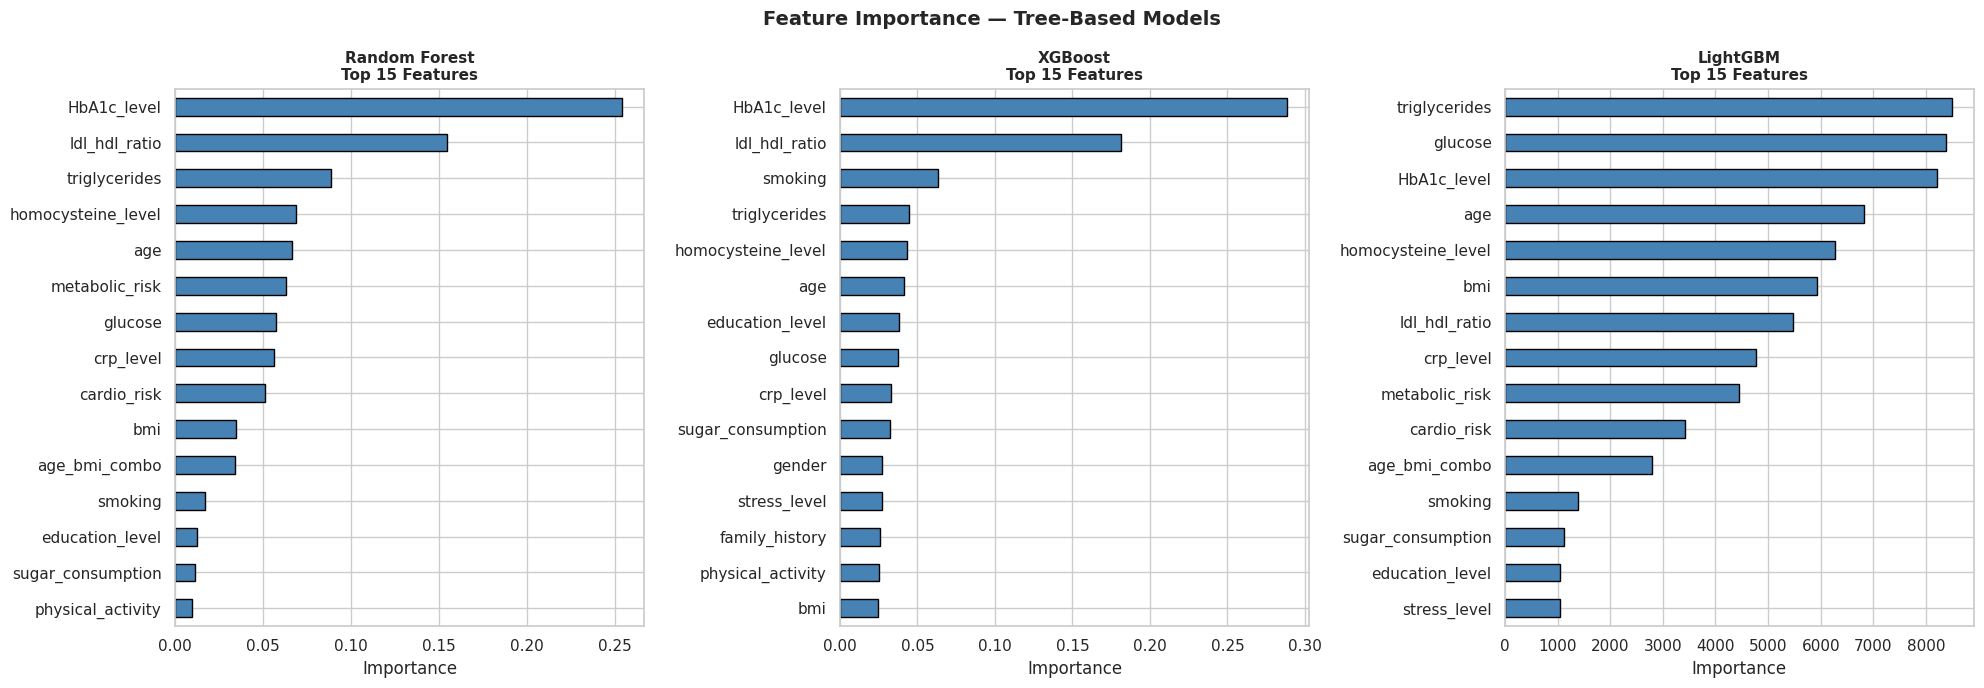

In [50]:
tree_models = ['Random Forest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, name in zip(axes, tree_models):
    model = trained_models[name]
    importances = pd.Series(model.feature_importances_,
                            index=X_train_res.columns)
    importances.nlargest(15).sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'{name}\nTop 15 Features', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance — Tree-Based Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##   22 — Full Classification Reports

In [51]:
for name, model in trained_models.items():
    X_eval = X_test_scaled if name in ['Logistic Regression', 'LinearSVC (SVM)'] else X_test
    y_pred = model.predict(X_eval)
    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


  Logistic Regression
              precision    recall  f1-score   support

          DI       0.26      0.12      0.17      6381
       DI_HT       0.03      0.38      0.05       280
    DI_HT_HY       0.02      0.22      0.03       169
       DI_HY       0.67      0.61      0.64     13294
          HT       0.04      0.40      0.08       517
       HT_HY       0.01      0.18      0.02       213
          HY       0.59      0.52      0.56     13957
           N       0.74      0.51      0.60     20930

    accuracy                           0.49     55741
   macro avg       0.30      0.37      0.27     55741
weighted avg       0.62      0.49      0.54     55741


  Random Forest
              precision    recall  f1-score   support

          DI       0.56      0.10      0.17      6381
       DI_HT       0.13      0.51      0.21       280
    DI_HT_HY       0.08      0.38      0.13       169
       DI_HY       0.72      0.93      0.81     13294
          HT       0.08      0.53     

##   23 — Final Summary & Best Model

╔══════════════════════════════════════════════════════════╗
║          FINAL MODEL COMPARISON SUMMARY                 ║
╠══════════════════════════════════════════════════════════╣
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
           LightGBM    0.7444     0.7582  0.7444    0.7250   0.9254
            XGBoost    0.7331     0.7640  0.7331    0.7179   0.9231
      Random Forest    0.6993     0.7735  0.6993    0.6963   0.9139
Logistic Regression    0.4868     0.6196  0.4868    0.5382   0.8606
    LinearSVC (SVM)    0.4907     0.6141  0.4907    0.5378   0.8334
╚══════════════════════════════════════════════════════════╝

🏆 Best Model  : LightGBM
   ROC-AUC     : 0.9254
   F1-Score    : 0.725


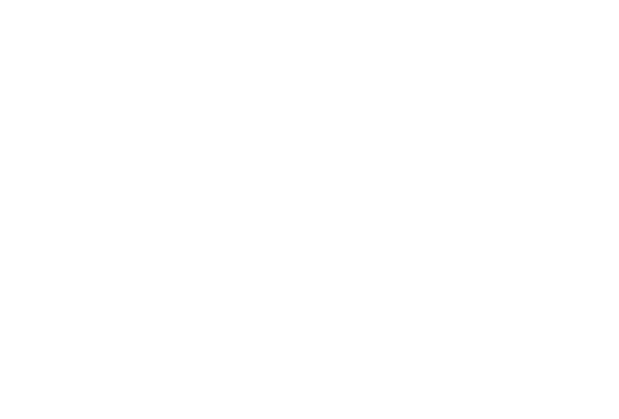

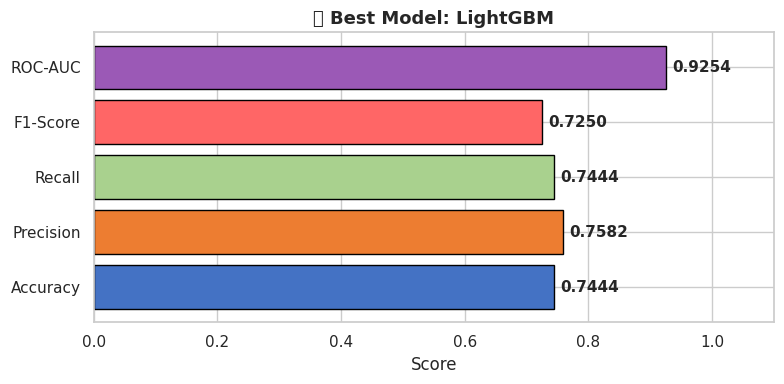


✅ Pipeline Complete!


In [52]:
print('╔══════════════════════════════════════════════════════════╗')
print('║          FINAL MODEL COMPARISON SUMMARY                 ║')
print('╠══════════════════════════════════════════════════════════╣')
print(results_df.to_string(index=False))
print('╚══════════════════════════════════════════════════════════╝')

best_model_name = results_df.iloc[0]['Model']
best_auc       = results_df.iloc[0]['ROC-AUC']
best_f1        = results_df.iloc[0]['F1-Score']

print(f'\n🏆 Best Model  : {best_model_name}')
print(f'   ROC-AUC     : {best_auc}')
print(f'   F1-Score    : {best_f1}')

# Highlight radar chart of best model
from matplotlib.patches import FancyBboxPatch
best_row = results_df[results_df['Model'] == best_model_name].iloc[0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_visible(False)
metrics_vals = best_row[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']].values

fig, ax2 = plt.subplots(figsize=(8, 4))
bars = ax2.barh(metrics, metrics_vals, color=['#4472C4','#ED7D31','#A9D18E','#FF6666','#9B59B6'],
               edgecolor='black')
ax2.set_xlim(0, 1.1)
for bar, val in zip(bars, metrics_vals):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
ax2.set_title(f'🏆 Best Model: {best_model_name}', fontsize=13, fontweight='bold')
ax2.set_xlabel('Score')
plt.tight_layout()
plt.show()

print('\n✅ Pipeline Complete!')